# Correlation & Mean-Reversion Spread Study

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.regression.rolling import RollingOLS
import statsmodels.api as sm
import yfinance as yf

pd.set_option("display.width", 140)
%matplotlib inline

In [ ]:
TICKER_A = "ES=F"
TICKER_B = "NQ=F"
TIMEFRAME = "1h"            # hourly bars
PERIOD = "730d"            # yfinance's max lookback for 1h interval

# --- strategy / study params (in HOURS, since bars are hourly) ---
CORR_WINDOW = 120             # ~5 trading days of hourly bars
BETA_WINDOW = 480             # ~20 trading days
Z_WINDOW = 120                # ~5 trading days

ENTRY_Z = 2.0
EXIT_Z = 0.5
STOP_Z = 4.0

COST_PER_TRADE = 0.5          # in spread points, round-trip friction/slippage

## 2. Data loading

In [3]:
# df = yf.download(Ticker, period="max", interval="15m")

a_df = yf.download(TICKER_A, period=PERIOD, interval=TIMEFRAME, progress=False, auto_adjust=True)
b_df = yf.download(TICKER_B, period=PERIOD, interval=TIMEFRAME, progress=False, auto_adjust=True)


a_df.columns.names = [None, None]
a_df.columns = a_df.columns.get_level_values(0)
a_df = a_df.drop(columns=["Volume"])

b_df.columns.names = [None, None]
b_df.columns = b_df.columns.get_level_values(0)
b_df = b_df.drop(columns=["Volume"])

In [4]:
df = pd.DataFrame({
    "A": a_df["Close"],
    "B": b_df["Close"]
}, index=a_df.index)

df

,A,B
Datetime,,
2023-10-31 00:00:00+00:00,1.061458,1.216057
2023-10-31 01:00:00+00:00,1.061233,1.215687
2023-10-31 02:00:00+00:00,1.060445,1.214831
2023-10-31 03:00:00+00:00,1.059771,1.214447
2023-10-31 04:00:00+00:00,1.059659,1.214093
...,...,...
2026-08-14 19:00:00+01:00,1.156872,1.353327
2026-08-14 20:00:00+01:00,1.157006,1.353363
2026-08-14 21:00:00+01:00,1.157274,1.353546


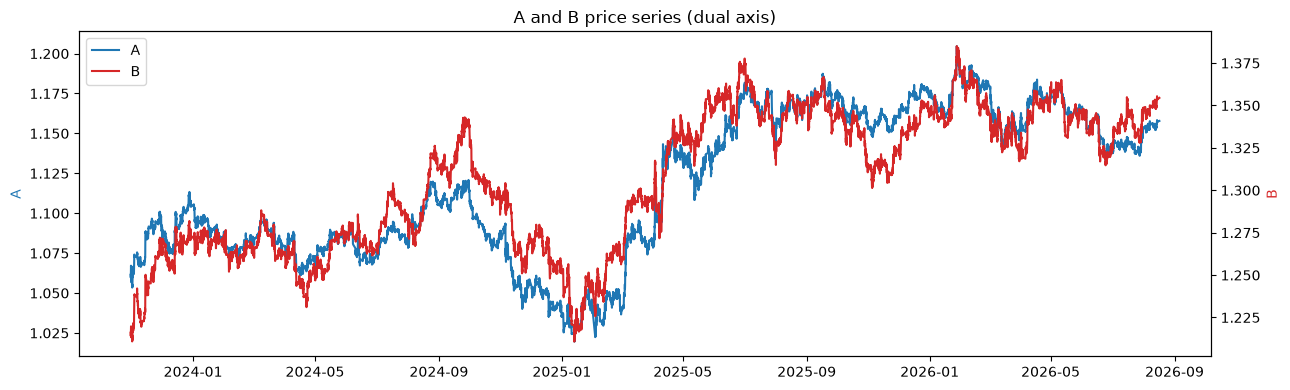

In [5]:
fig, ax_a = plt.subplots(figsize=(13, 4))
ax_b = ax_a.twinx()

ax_a.plot(df.index, df["A"], color="#1f77b4", label="A")
ax_b.plot(df.index, df["B"], color="#d62728", label="B")

ax_a.set_ylabel("A", color="#1f77b4")
ax_b.set_ylabel("B", color="#d62728")

ax_a.set_title("A and B price series (dual axis)")

lines1, labels1 = ax_a.get_legend_handles_labels()
lines2, labels2 = ax_b.get_legend_handles_labels()

ax_a.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

## 3. Correlation study

Full-sample return correlation (A vs B): 0.7937
Rolling 120-bar correlation: mean=0.7878, min=0.3977, max=0.9525


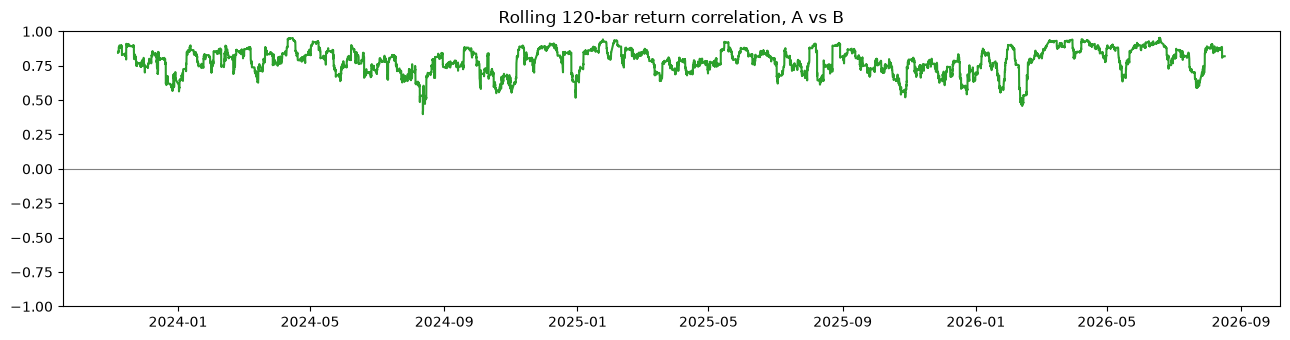

In [6]:
rets = df.pct_change().dropna()

full_corr = rets["A"].corr(rets["B"])
rolling_corr = rets["A"].rolling(CORR_WINDOW).corr(rets["B"])

print(f"Full-sample return correlation (A vs B): {full_corr:.4f}")
print(f"Rolling {CORR_WINDOW}-bar correlation: mean={rolling_corr.mean():.4f}, "f"min={rolling_corr.min():.4f}, max={rolling_corr.max():.4f}")

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(rolling_corr.index, rolling_corr.values, color="#2ca02c")
ax.axhline(0, color="gray", lw=0.8)
ax.set_ylim(-1, 1)
ax.set_title(f"Rolling {CORR_WINDOW}-bar return correlation, A vs B")

plt.tight_layout()
plt.show()

## 4. Hedge-ratio-adjusted spread

estimate a rolling hedge ratio (beta) via OLS:

```
A_t = alpha + beta * B_t + spread_t
```

and treat `spread_t` as the mean-reverting quantity. Beta is refit on a rolling window so it adapts to slow drift in the relationship (e.g. tech's growing weight in the S&P 500 pulls A and B closer over time).

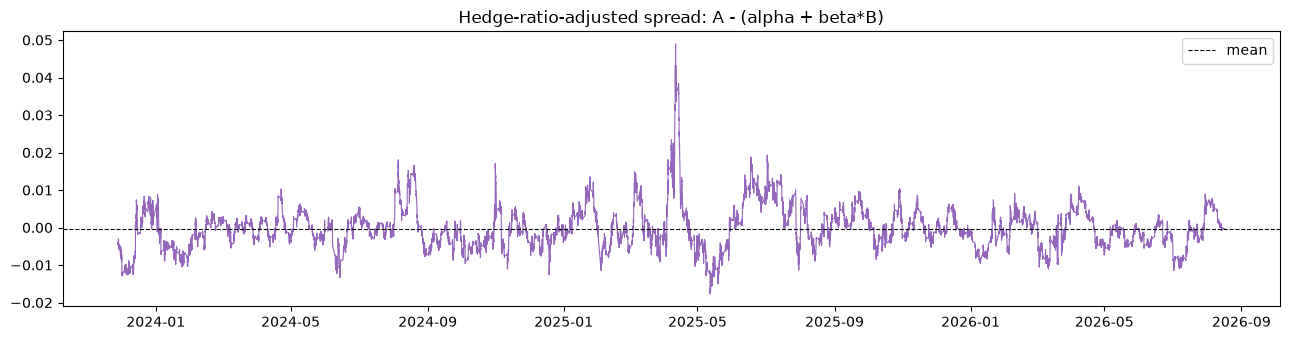

In [7]:
Y = df["A"]
X = sm.add_constant(df["B"])
rolling_model = RollingOLS(Y, X, window=BETA_WINDOW)
fit = rolling_model.fit()

beta = fit.params["B"]
alpha = fit.params["const"]
spread = (df["A"] - (alpha + beta * df["B"])).dropna()
beta = beta.reindex(spread.index)

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(spread.index, spread.values, color="#9467bd", lw=0.8)
ax.axhline(spread.mean(), color="black", lw=0.8, ls="--", label="mean")
ax.set_title("Hedge-ratio-adjusted spread: A - (alpha + beta*B)")

ax.legend()
plt.tight_layout()
plt.show()

## 5. Stationarity test (ADF)

A real mean-reversion strategy needs the spread to be statistically stationary — not just "look like" it reverts on a chart.

In [8]:
result = adfuller(spread.dropna(), autolag="AIC")
stat, pvalue, lags, nobs, crit_values, _ = result

print(f"ADF statistic: {stat:.4f}")
print(f"p-value:       {pvalue:.4f}")
print("Critical values:", {k: round(v, 3) for k, v in crit_values.items()})

if pvalue < 0.05:
    print("=> Spread appears stationary (mean-reverting) at 5% significance.")
else:
    print("=> Spread does NOT reject the unit-root null -- mean reversion is not "
          "statistically supported on this sample. Don't trade a non-stationary spread.")

ADF statistic: -7.5533
p-value:       0.0000
Critical values: {'1%': np.float64(-3.431), '5%': np.float64(-2.862), '10%': np.float64(-2.567)}
=> Spread appears stationary (mean-reverting) at 5% significance.


## 6. Mean-reversion strategy

Rules (classic pairs-trading / stat-arb):
- `z` = rolling z-score of the spread
- `z > +ENTRY_Z` → spread is rich: **short** the spread (short ES, long NQ×beta)
- `z < -ENTRY_Z` → spread is cheap: **long** the spread (long ES, short NQ×beta)
- `|z| < EXIT_Z` → flatten (reverted to mean)
- `|z| > STOP_Z` → hard stop (relationship may have broken down)

In [9]:
def zscore(series, window):
    m = series.rolling(window).mean()
    s = series.rolling(window).std()
    return (series - m) / s

z = zscore(spread, Z_WINDOW)
bt = pd.DataFrame({"spread": spread, "beta": beta, "z": z}).dropna()

position = np.zeros(len(bt))
pos = 0
for i in range(1, len(bt)):
    zi = bt["z"].iloc[i]
    if pos == 0:
        if zi > ENTRY_Z: pos = -1
        elif zi < -ENTRY_Z: pos = 1
    else:
        if abs(zi) < EXIT_Z or abs(zi) > STOP_Z: pos = 0
    position[i] = pos

bt["position"] = position
bt["spread_change"] = bt["spread"].diff().fillna(0)
bt["raw_pnl"] = bt["position"].shift(1).fillna(0) * bt["spread_change"]

trade_change = bt["position"].diff().fillna(bt["position"]).abs()
bt["costs"] = trade_change * COST_PER_TRADE
bt["pnl"] = bt["raw_pnl"] - bt["costs"]
bt["equity"] = bt["pnl"].cumsum()

bt

,spread,beta,z,position,spread_change,raw_pnl,costs,pnl,equity
Datetime,,,,,,,,,
2023-12-05 04:00:00+00:00,-0.009952,0.602040,-0.904445,0.0,0.000000,0.000000,0.0,0.000000,0.000000
2023-12-05 05:00:00+00:00,-0.009781,0.600028,-0.827581,0.0,0.000171,0.000000,0.0,0.000000,0.000000
2023-12-05 06:00:00+00:00,-0.010649,0.597979,-1.127296,0.0,-0.000868,-0.000000,0.0,-0.000000,0.000000
2023-12-05 07:00:00+00:00,-0.011753,0.596026,-1.504018,0.0,-0.001104,-0.000000,0.0,-0.000000,0.000000
2023-12-05 08:00:00+00:00,-0.010341,0.594045,-0.971699,0.0,0.001411,0.000000,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...
2026-08-14 19:00:00+01:00,-0.000251,0.838735,-1.106777,1.0,0.000043,0.000043,0.0,0.000043,-187.404317
2026-08-14 20:00:00+01:00,-0.000163,0.839096,-1.041832,1.0,0.000088,0.000088,0.0,0.000088,-187.404229
2026-08-14 21:00:00+01:00,-0.000070,0.839846,-0.971149,1.0,0.000092,0.000092,0.0,0.000092,-187.404136


## 7. Backtest stats

In [10]:
n_trades = int((trade_change > 0).sum())
total_pnl = bt["pnl"].sum()
daily_like = bt["pnl"][bt["pnl"] != 0]
sharpe = (np.sqrt(252) * daily_like.mean() / daily_like.std()
          if len(daily_like) > 1 and daily_like.std() > 0 else float("nan"))
running_max = bt["equity"].cummax()
drawdown = bt["equity"] - running_max
max_dd = drawdown.min()

trade_pnls, cur, in_trade = [], 0.0, False
for i in range(len(bt)):
    if bt["position"].iloc[i] != 0:
        in_trade = True
        cur += bt["pnl"].iloc[i]
    else:
        if in_trade:
            trade_pnls.append(cur)
            cur = 0.0
            in_trade = False
if in_trade:
    trade_pnls.append(cur)
trade_pnls = np.array(trade_pnls)
win_rate = (trade_pnls > 0).mean() if len(trade_pnls) else float("nan")

print(f"Number of round-trip trades: {n_trades}")
print(f"Total PnL (spread pts):      {total_pnl:.2f}")
print(f"Annualized Sharpe (approx):  {sharpe:.2f}")
print(f"Max drawdown (spread pts):   {max_dd:.2f}")
print(f"Win rate:                    {win_rate:.1%}" if len(trade_pnls) else "Win rate: n/a")

print("\nFor Es - Nq for example: To convert to $, multiply ES pts by $50/pt and NQ pts by $20/pt (CME e-mini \n"
      "multipliers; $5/$2 for the Micro versions) -- the two legs have different point \n"
      "values, so position sizing must weight contracts by (multiplier x beta), not beta alone.")

Number of round-trip trades: 375
Total PnL (spread pts):      -187.40
Annualized Sharpe (approx):  -3.62
Max drawdown (spread pts):   -187.40
Win rate:                    0.0%

For Es - Nq for example: To convert to $, multiply ES pts by $50/pt and NQ pts by $20/pt (CME e-mini 
multipliers; $5/$2 for the Micro versions) -- the two legs have different point 
values, so position sizing must weight contracts by (multiplier x beta), not beta alone.


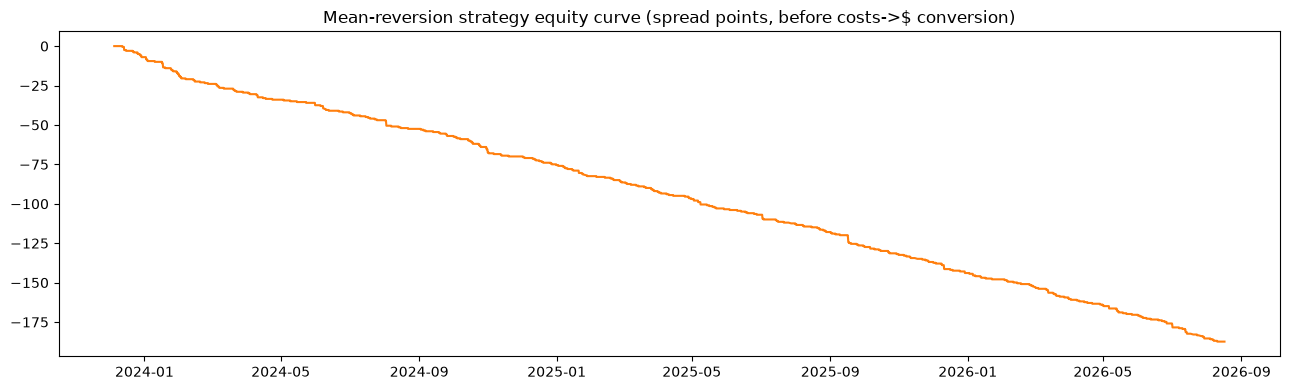

In [11]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(bt.index, bt["equity"], color="#ff7f0e")
ax.set_title("Mean-reversion strategy equity curve (spread points, before costs->$ conversion)")
plt.tight_layout()
plt.show()